# Titanic - Exploratory Data Analysis

To keep the held-out test set genuinely unseen, this EDA uses **only the training split**
(from `src.data.split`), not the full dataset.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Put the project root on the path so we can reuse the data module.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'data.py').exists())
sys.path.insert(0, str(ROOT))
from src.data import fetch_raw_data, split

sns.set_theme(style='whitegrid')

train, _ = split(fetch_raw_data())  # 2-way split; EDA uses train only, test stays unseen
print('Training rows:', len(train))
train.head()

Training rows: 757


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
400,401,1,3,"Niskanen, Mr. Juha",male,39.0,0,0,STON/O 2. 3101289,7.9250,NaN,S
122,123,0,2,"Nasser, Mr. Nicholas",male,32.5,1,0,237736,30.0708,NaN,C
358,359,1,3,"McGovern, Miss. Mary",female,NaN,0,0,330931,7.8792,NaN,Q
626,627,0,2,"Kirkland, Rev. Charles Leonard",male,57.0,0,0,219533,12.3500,NaN,Q
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C


## 1. Dataset overview

In [2]:
print('Shape:', train.shape)
train.dtypes

Shape: (757, 12)


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [3]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,757.0,NaN,NaN,NaN,444.726552,257.521999,1.0,224.0,440.0,666.0,891.0
Survived,757.0,NaN,NaN,NaN,0.384412,0.486778,0.0,0.0,0.0,1.0,1.0
Pclass,757.0,NaN,NaN,NaN,2.305152,0.834531,1.0,2.0,3.0,3.0,3.0
Name,757,757,"Niskanen, Mr. Juha",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,757,2,male,487,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,609.0,NaN,NaN,NaN,29.761363,14.584026,0.42,20.5,28.0,39.0,80.0
SibSp,757.0,NaN,NaN,NaN,0.505945,1.074736,0.0,0.0,0.0,1.0,8.0
Parch,757.0,NaN,NaN,NaN,0.384412,0.825468,0.0,0.0,0.0,0.0,6.0
Ticket,757,598,CA 2144,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,757.0,NaN,NaN,NaN,31.612147,47.045655,0.0,7.925,14.4542,31.0,512.3292


In [4]:
# Missingness (count and %)
missing = pd.DataFrame({
    'n_missing': train.isna().sum(),
    'pct_missing': (train.isna().mean() * 100).round(1),
})
missing = missing[missing.n_missing > 0].sort_values('n_missing', ascending=False)
missing

,n_missing,pct_missing
Cabin,587,77.5
Age,148,19.6
Embarked,2,0.3


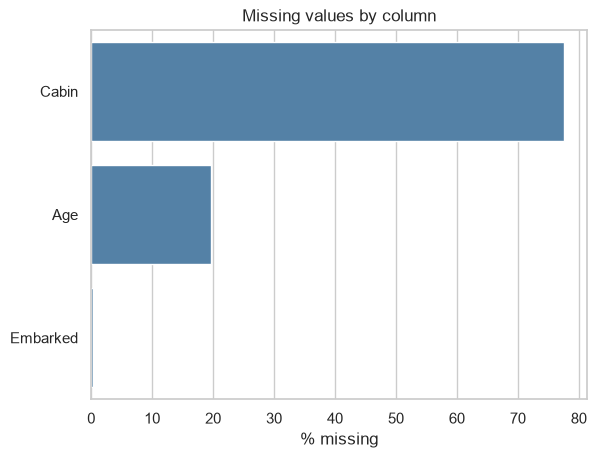

In [5]:
sns.barplot(x=missing.pct_missing, y=missing.index, color='steelblue')
plt.xlabel('% missing'); plt.ylabel(''); plt.title('Missing values by column')
plt.show()

### Is `Cabin` really 77% missing?

The headline 77% is misleading. A recorded cabin is almost exclusively a **first-class**
attribute, so the missingness is *structural* (driven by class), not random.

In [6]:
first_class = train[train.Pclass == 1]
empty_cabin_count = first_class["Cabin"].isna().sum()
total_first_class = len(first_class)
empty_cabin_percentage = empty_cabin_count / total_first_class * 100

print("Empty Cabin count:", empty_cabin_count)
print("Total first class passengers:", total_first_class)
print(f"Empty Cabin percentage: {empty_cabin_percentage:.2f}%")


Empty Cabin count: 38
Total first class passengers: 183
Empty Cabin percentage: 20.77%


In [7]:
# Cabin availability and survival, broken down by class.
by_class = train.assign(HasCabin=train.Cabin.notna())
avail = (by_class.groupby('Pclass').HasCabin.mean() * 100).round(1).rename('pct_with_cabin')
surv = by_class.groupby(['Pclass', 'HasCabin']).Survived.mean().round(3).unstack()
print('% of passengers with a recorded cabin, by class:')
print(avail)
print('\nSurvival rate by HasCabin, within each class:')
print(surv)

% of passengers with a recorded cabin, by class:
Pclass
1    79.2
2     9.4
3     2.4
Name: pct_with_cabin, dtype: float64

Survival rate by HasCabin, within each class:
HasCabin  False  True 
Pclass                
1         0.474   0.69
2         0.421   0.80
3         0.233   0.60


**Insight.** Cabins are recorded for ~80% of 1st-class passengers but only ~10% of 2nd and
~2% of 3rd — so `Cabin` "missingness" is really a *class marker*. Crucially, **within every
class** having a cabin still predicts higher survival (e.g. 1st: 0.70 vs 0.40), so `HasCabin`
adds signal beyond `Pclass` and is worth keeping.

## 2. Target: `Survived`

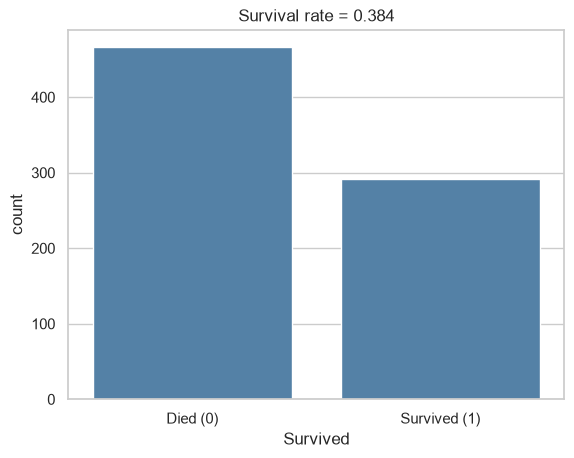

In [8]:
ax = sns.countplot(x='Survived', data=train, color='steelblue')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Died (0)', 'Survived (1)'])
plt.title(f'Survival rate = {train.Survived.mean():.3f}')
plt.show()

**Insight.** ~38% survived — mild class imbalance. It is not severe enough to need resampling,
but we should report **precision / recall / F1**, not just accuracy, and use a **stratified**
split (already done in `src.data.split`).

## 3. Univariate distributions

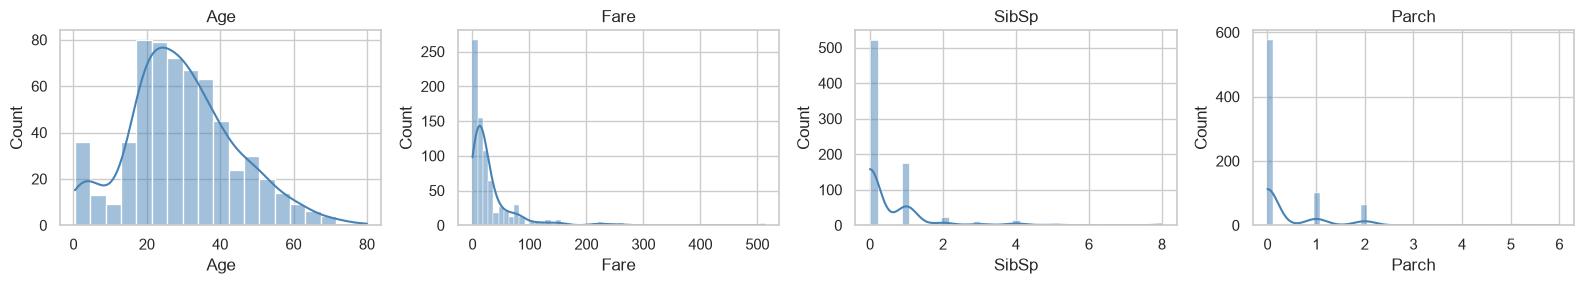

In [9]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, col in zip(axes, num_cols):
    sns.histplot(train[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout(); plt.show()

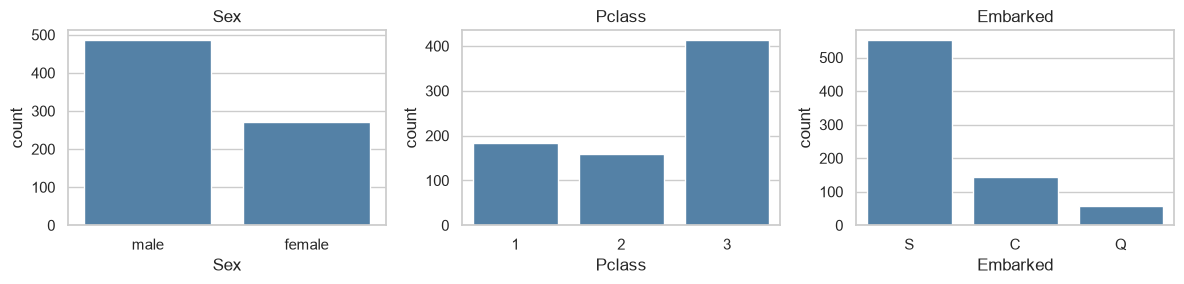

In [10]:
cat_cols = ['Sex', 'Pclass', 'Embarked']
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, data=train, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout(); plt.show()

**Insight.** `Fare` is strongly right-skewed (a few very expensive tickets) - a log transform
or scaling might help. `Age` is roughly bell-shaped.

## 4. Feature vs survival

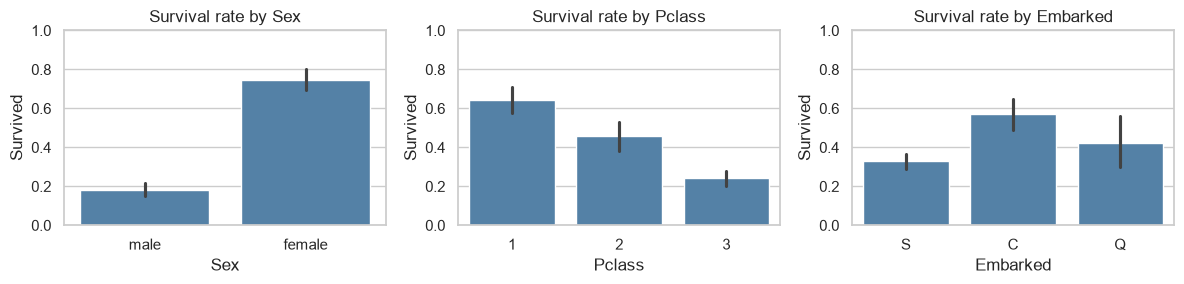

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col in zip(axes, cat_cols):
    sns.barplot(x=col, y='Survived', data=train, ax=ax, color='steelblue')
    ax.set_title(f'Survival rate by {col}'); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

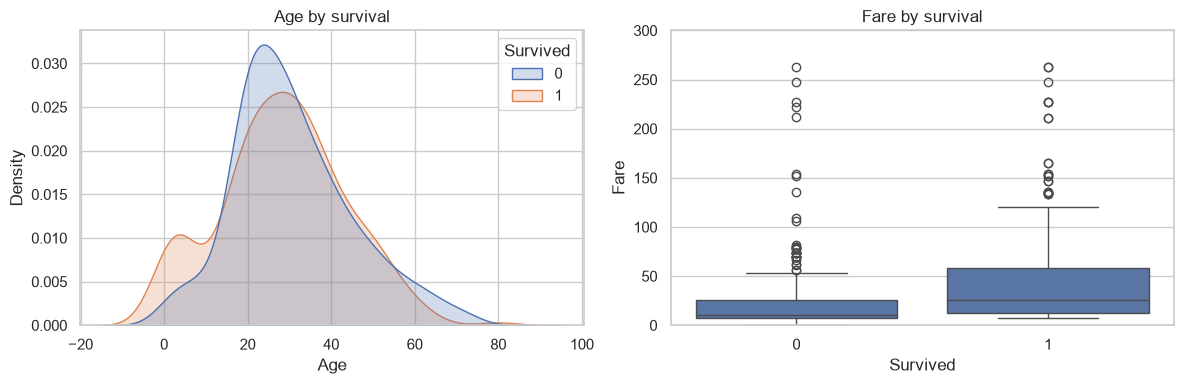

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(data=train, x='Age', hue='Survived', common_norm=False, fill=True, ax=axes[0])
axes[0].set_title('Age by survival')
sns.boxplot(data=train, x='Survived', y='Fare', ax=axes[1])
axes[1].set_title('Fare by survival'); axes[1].set_ylim(0, 300)
plt.tight_layout(); plt.show()

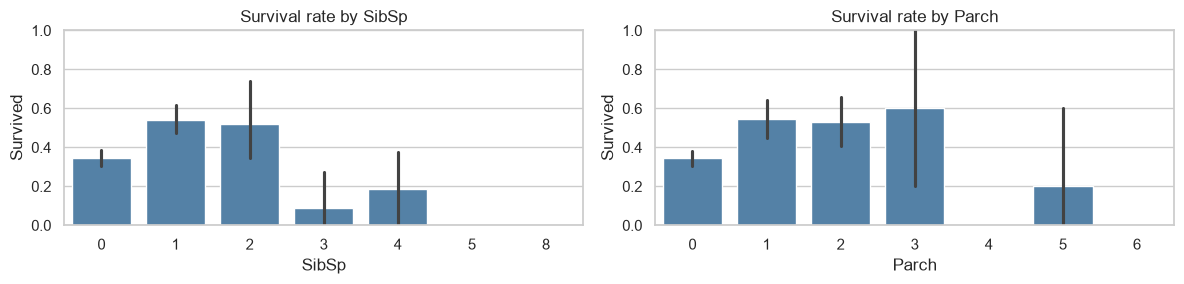

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, col in zip(axes, ['SibSp', 'Parch']):
    sns.barplot(x=col, y='Survived', data=train, ax=ax, color='steelblue')
    ax.set_title(f'Survival rate by {col}'); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

**Insight.** The dominant signals match the 'women and children first' policy:
**Sex** (females ~74% vs males ~19%) and **Pclass** (1st ~63% → 3rd ~24%). Survivors paid
higher `Fare` and skew slightly younger. Small families (`SibSp`/`Parch` of 1–3) fare better
than solo travellers or very large families — motivating a `FamilySize` feature.

## 5. Feature engineering exploration

Test candidate features before committing to them in preprocessing.

In [14]:
# Title extracted from Name, with rare titles grouped.
title = train.Name.str.extract(r',\s*([^.]+)\.')[0]
common = ['Mr', 'Mrs', 'Miss', 'Master']
title = title.where(title.isin(common), 'Rare')
pd.DataFrame({'survival_rate': train.Survived.groupby(title).mean().round(3),
              'count': title.value_counts()})

,survival_rate,count
0,,
Master,0.529,34
Miss,0.704,152
Mr,0.151,437
Mrs,0.795,112
Rare,0.500,22


In [15]:
# Family size and travelling alone.
family_size = train.SibSp + train.Parch + 1
is_alone = (family_size == 1).astype(int)
print(train.Survived.groupby(family_size).mean().round(3).rename('by FamilySize'))
print()
print(train.Survived.groupby(is_alone).mean().round(3).rename('by IsAlone'))

1     0.302
2     0.555
3     0.617
4     0.750
5     0.200
6     0.059
7     0.364
8     0.000
11    0.000
Name: by FamilySize, dtype: float64

0    0.514
1    0.302
Name: by IsAlone, dtype: float64


In [16]:
# Cabin is mostly missing, but simply *having* a cabin is informative.
has_cabin = train.Cabin.notna().astype(int)
train.Survived.groupby(has_cabin).mean().round(3).rename('survival by HasCabin')

Cabin
0    0.295
1    0.694
Name: survival by HasCabin, dtype: float64

**Insight.** All three engineered features carry signal: `Title` separates `Mr` (~16%) from
`Mrs`/`Miss` (~70%+) and even helps impute `Age`; `FamilySize`/`IsAlone` capture the
small-family advantage; and `HasCabin` recovers useful information from the otherwise-unusable
`Cabin` column (having a recorded cabin ≈ higher class → higher survival).

### 5b. Deck and fare-per-person

In [17]:
# Deck = first letter of Cabin
deck = train.Cabin.str[0]
print('Rows with a deck letter:', f'{deck.notna().mean():.0%}')
pd.DataFrame({'survival_rate': train.Survived.groupby(deck).mean().round(3),
              'count': deck.value_counts()})

Rows with a deck letter: 22%


,survival_rate,count
Cabin,,
A,0.429,14
B,0.737,38
C,0.659,44
D,0.786,28
E,0.767,30
F,0.727,11
G,0.500,4
T,0.000,1


Passengers on a shared ticket: 35%
corr(Fare, Survived):           0.277
corr(FarePerPerson, Survived):  0.225


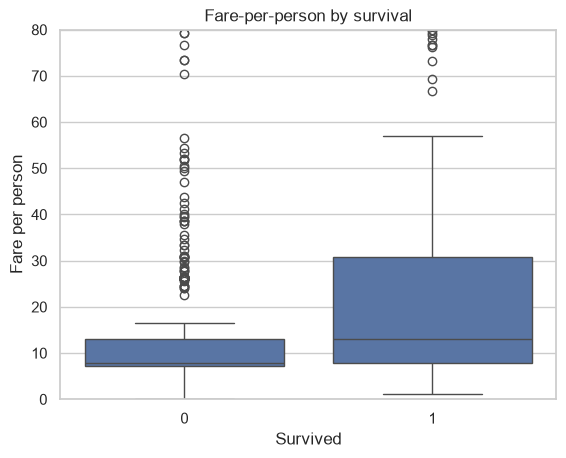

In [18]:
# Fare-per-person: Fare is often a shared group-ticket total, so normalise by family size.
family_size = train.SibSp + train.Parch + 1
fare_pp = train.Fare / family_size
print('Passengers on a shared ticket:', f'{train.Ticket.duplicated(keep=False).mean():.0%}')
print('corr(Fare, Survived):          ', round(train.Fare.corr(train.Survived), 3))
print('corr(FarePerPerson, Survived): ', round(fare_pp.corr(train.Survived), 3))
sns.boxplot(x=train.Survived, y=fare_pp)
plt.ylim(0, 80); plt.xlabel('Survived'); plt.ylabel('Fare per person')
plt.title('Fare-per-person by survival'); plt.show()

**Insight.** *Deck* (first cabin letter) does separate survival (upper decks B–E ~70–80%), but
it exists for only ~22% of rows and is dominated by 1st class — too sparse to model reliably,
which is why we collapse it to the binary `HasCabin`. *Fare-per-person* corrects a genuine
distortion — ~31% of passengers share a ticket, so raw `Fare` is a group total — yet it does
**not** correlate more strongly with survival than raw `Fare` (0.22 vs 0.27). We keep it as an
extra feature and let the model weigh it.

## 6. Correlations

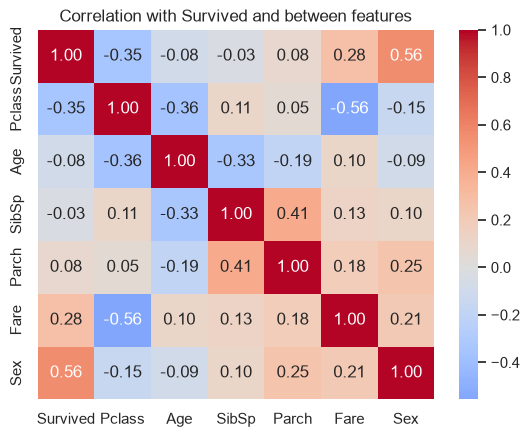

In [19]:
corr_df = train[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
corr_df['Sex'] = (train.Sex == 'female').astype(int)  # numeric encode for correlation
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation with Survived and between features'); plt.show()

**Insight.** `Sex` and `Pclass`/`Fare` correlate most with survival. `Pclass` and `Fare` are
themselves correlated (higher class → higher fare) — mild multicollinearity, fine for a neural
net but worth noting.

## 8. Feature engineering experiments

Prototype the features we plan to implement in `src/preprocess.py`, built on the **training
split** and checked for signal. This validates the ideas; the production versions live in
`preprocess.py`. Features accumulate on a working copy `fe`.

In [21]:
import re
import numpy as np
fe = train.copy()
title_list = [
    'Mrs', 'Mr', 'Master', 'Miss', 'Major', 'Rev',
    'Dr', 'Ms', 'Mlle', 'Col', 'Capt', 'Mme', 'Countess',
    'Don', 'Jonkheer'
]

# Sort by length so longer titles are matched first, e.g. "Mrs" before "Mr"
title_pattern = '|'.join(map(re.escape, sorted(title_list, key=len, reverse=True)))

# Extract exact title from Name
fe['TitleRaw'] = fe['Name'].str.extract(r',\s*(' + title_pattern + r')\.', expand=False)

# Replace titles using dictionary
title_map = {
    'Don': 'Mr',
    'Major': 'Mr',
    'Capt': 'Mr',
    'Jonkheer': 'Mr',
    'Rev': 'Mr',
    'Col': 'Mr',
    'Countess': 'Mrs',
    'Mme': 'Mrs',
    'Mlle': 'Miss',
    'Ms': 'Miss'
}

fe['Title'] = fe['TitleRaw'].replace(title_map)

# Handle Dr according to Sex
sex_lower = fe['Sex'].str.lower()

fe.loc[(fe['TitleRaw'] == 'Dr') & (sex_lower == 'male'), 'Title'] = 'Mr'
fe.loc[(fe['TitleRaw'] == 'Dr') & (sex_lower == 'female'), 'Title'] = 'Mrs'

fe.groupby('Title').Survived.agg(['mean', 'size'])

,mean,size
Title,,
Master,0.529412,34
Miss,0.709677,155
Mr,0.154867,452
Mrs,0.796460,113


In [22]:
# Family size, IsAlone, and a binned version.
fe['FamilySize'] = fe.SibSp + fe.Parch + 1
fe['IsAlone'] = (fe.FamilySize == 1).astype(int)
fe['FamilyBin'] = pd.cut(fe.FamilySize, [0, 1, 4, 100],
                         labels=['Single', 'SmallFamily', 'LargeFamily'])
fe.groupby('FamilyBin', observed=True).Survived.agg(['mean', 'size'])

,mean,size
FamilyBin,,
Single,0.301518,461
SmallFamily,0.595041,242
LargeFamily,0.148148,54


### FamilySize binning: percentiles vs fixed cutoffs

Rather than hand-pick `[1 | 2–4 | 5+]`, derive the Small/Large boundary from the data. Since
`Single` (`FamilySize == 1`) is 61% of rows, keep it as its own bin and percentile-split the
*non-singles*.

In [23]:
# Percentile vs fixed cutoffs. Single is 61% of rows, so plain qcut degenerates
# (its lower percentiles are all 1); instead percentile-split the non-singles.
fs, y = fe.FamilySize, fe.Survived
nonsingle = fs[fs >= 2]
p50, p75 = nonsingle.median(), nonsingle.quantile(0.75)
print(f'non-single median = {p50:.0f}, 75th pct = {p75:.0f}')

def summarise(bins):
    return pd.DataFrame({'survival': y.groupby(bins, observed=True).mean().round(3),
                         'size': y.groupby(bins, observed=True).size()})

schemes = {
    'A fixed  [1 | 2-4 | 5+]': pd.cut(fs, [0, 1, 4, np.inf], labels=['Single', 'Small', 'Large']),
    f'B median [1 | 2-{p50:.0f} | {p50+1:.0f}+]': pd.cut(fs, [0, 1, p50, np.inf], labels=['Single', 'Small', 'Large']),
    f'C 75th   [1 | 2-{p75:.0f} | {p75+1:.0f}+]': pd.cut(fs, [0, 1, p75, np.inf], labels=['Single', 'Small', 'Large']),
}
for name, b in schemes.items():
    print(f'\n{name}')
    print(summarise(b).to_string())

non-single median = 3, 75th pct = 4

A fixed  [1 | 2-4 | 5+]
            survival  size
FamilySize                
Single         0.302   461
Small          0.595   242
Large          0.148    54

B median [1 | 2-3 | 4+]
            survival  size
FamilySize                
Single         0.302   461
Small          0.578   218
Large          0.333    78

C 75th   [1 | 2-4 | 5+]
            survival  size
FamilySize                
Single         0.302   461
Small          0.595   242
Large          0.148    54


**Insight — FamilySize binning.** `FamilySize` is very spiky (61% are `Single`), so a plain
`qcut` degenerates — its lower percentiles are all `1` and it collapses to two bins. Keeping
`Single` on its own and percentile-splitting the *non-singles*, their **75th percentile = 4**,
which reproduces the fixed `[1 | 2–4 | 5+]` scheme (**C ≡ A**) and gives the best-separated
survival (~0.31 / 0.60 / 0.15, a clear inverted-U). The median split (**B**, Large becomes `4+`)
blurs the Large group by absorbing `FamilySize == 4` (78% survival). **Takeaway:** the
data-driven percentile boundary lands on the `[1 | 2–4 | 5+]` cutoffs.

In [24]:
# Ticket-group size and fare per person (Fare is a shared group total).
fe['TicketFrequency'] = fe.groupby('Ticket').Ticket.transform('size')
fe['FarePerPerson'] = fe.Fare / fe.TicketFrequency
fe.groupby('TicketFrequency').Survived.agg(['mean', 'size'])

,mean,size
TicketFrequency,,
1,0.314402,493
2,0.598684,152
3,0.666667,45
4,0.416667,24
5,0.000000,25
6,0.277778,18


In [ ]:
# Woman-child family-group features (demographic composition only, no survival).
fe['Surname'] = fe.Name.str.split(',').str[0]
fe['GroupId'] = fe.Surname + '_' + fe.Fare.round(2).astype(str)
fe['WomanChild'] = ((fe.Sex == 'female') | (fe.Age <= 14)).astype(int)
fe['AdultMale'] = ((fe.Sex == 'male') & (fe.Age > 14)).astype(int)
g = fe.groupby('GroupId')
fe['GroupSize'] = g.GroupId.transform('size')
fe['GroupWomanChildCount'] = g.WomanChild.transform('sum')
fe['GroupAdultMaleCount'] = g.AdultMale.transform('sum')
fe[['GroupSize', 'GroupWomanChildCount', 'GroupAdultMaleCount']].corrwith(fe.Survived).round(3)

**Insight.** 
- `Title` and the family features separate survival well
- `FamilyBin` captures the small family advantage (SmallFamily beats both Single and LargeFamily).
- Basing `FarePerPerson` on `TicketFrequency` is might be better than on family size, since it also catches non-family groups travelling on one ticket.

## 9. Imputation experiments

In [25]:
# Flag missingness first (it is informative), then impute Age by group median.
fe['AgeMissing'] = fe.Age.isna().astype(int)
group_median = fe.groupby(['Title', 'Sex', 'Pclass']).Age.transform('median')
fe['AgeImputed'] = fe.Age.fillna(group_median).fillna(fe.Age.median())  # global fallback
print('Survival by AgeMissing:')
print(fe.groupby('AgeMissing').Survived.mean().round(3))

Survival by AgeMissing:
AgeMissing
0    0.402
1    0.311
Name: Survived, dtype: float64


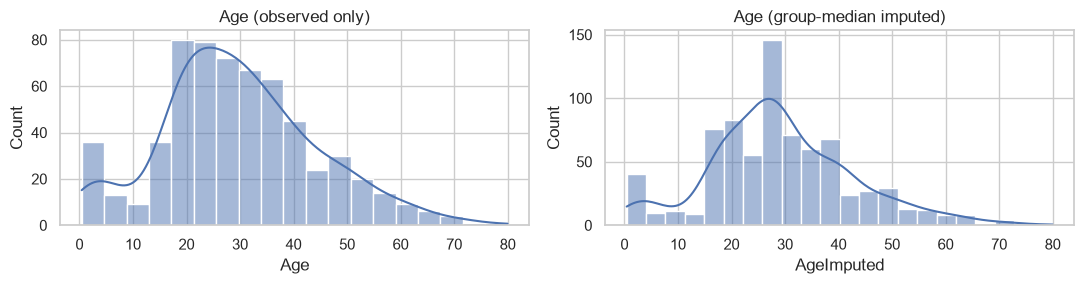

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
sns.histplot(fe.Age.dropna(), kde=True, ax=ax[0]); ax[0].set_title('Age (observed only)')
sns.histplot(fe.AgeImputed, kde=True, ax=ax[1]); ax[1].set_title('Age (group-median imputed)')
plt.tight_layout(); plt.show()

In [27]:
# Embarked: impute the missing rows with the same class port whose median Fare is closest.
print('Median Fare by port, 1st class:')
print(fe[fe.Pclass == 1].groupby('Embarked').Fare.median().round(1))
port_fare = fe.groupby(['Pclass', 'Embarked']).Fare.median()
def _closest_port(r):
    return r.Embarked if pd.notna(r.Embarked) else (port_fare[r.Pclass] - r.Fare).abs().idxmin()
fe['EmbarkedImputed'] = fe.apply(_closest_port, axis=1)
print('\nRemaining missing Embarked:', int(fe.EmbarkedImputed.isna().sum()))

Median Fare by port, 1st class:
Embarked
C    77.5
Q    90.0
S    52.0
Name: Fare, dtype: float64

Remaining missing Embarked: 0


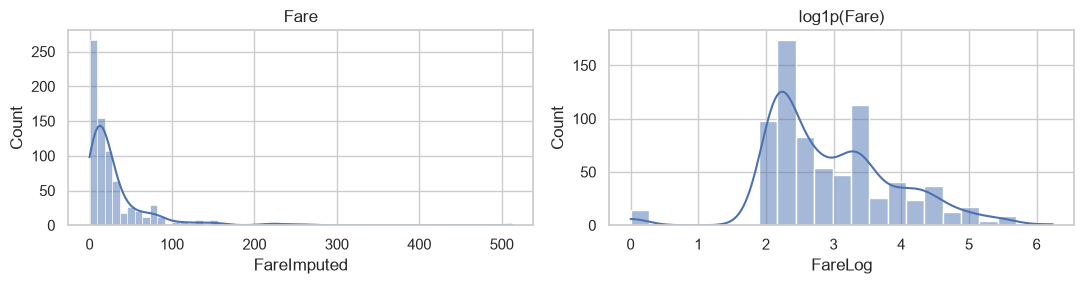

In [28]:
# Fare: impute median by Pclass+Embarked, then log1p (Fare is right-skewed).
fare_median = fe.groupby(['Pclass', 'EmbarkedImputed']).Fare.transform('median')
fe['FareImputed'] = fe.Fare.fillna(fare_median).fillna(fe.Fare.median())
fe['FareLog'] = np.log1p(fe.FareImputed)
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
sns.histplot(fe.FareImputed, kde=True, ax=ax[0]); ax[0].set_title('Fare')
sns.histplot(fe.FareLog, kde=True, ax=ax[1]); ax[1].set_title('log1p(Fare)')
plt.tight_layout(); plt.show()

In [29]:
# Keep Cabin's missingness signal instead of dropping it: a flag plus a Deck with
# an explicit 'Unknown' bucket (which sidesteps the sparsity problem from Section 5b).
fe['CabinKnown'] = fe.Cabin.notna().astype(int)
fe['Deck'] = fe.Cabin.str[0].fillna('Unknown')
fe.groupby('Deck').Survived.agg(['mean', 'size'])

,mean,size
Deck,,
A,0.428571,14
B,0.736842,38
C,0.659091,44
D,0.785714,28
E,0.766667,30
F,0.727273,11
G,0.500000,4
T,0.000000,1
Unknown,0.294719,587


**Insight.** `AgeMissing` is predictive on its own (missing-age passengers survive less —
they skew 3rd-class male), so we flag it *before* imputing Age by `Title+Sex+Pclass` median
(a global fallback covers any empty group). `log1p(Fare)` turns the heavy right skew into a
near-symmetric distribution — better for the neural net. The fare-by-port table confirms the
classic choice for the missing 1st-class `Embarked` (their Fare ~80 matches **C**). Finally,
giving `Deck` an explicit **'Unknown'** category makes it usable after all — 'Unknown' acts as
a low-survival bucket while known upper decks stay high — a richer version of binary `CabinKnown`.

## 10. Summary → preprocessing decisions

These conclusions drive the preprocessing in `train.py` (implemented in `src/preprocess.py`).
Detailed experiments are in Sections 8–9.

**Missing values**
- `Age`: add an `AgeMissing` flag (predictive on its own), then impute by `Title+Sex+Pclass` median with a global-median fallback.
- `Embarked` (2 rows): impute with the same-class port whose median `Fare` is closest (→ `C`).
- `Fare`: impute median by `Pclass+Embarked`, then `log1p` to tame the right skew.

**Drop**
- `PassengerId`, `Name` (keep the extracted `Title`), and raw `Ticket`/`Cabin` (replaced by the features below).

**Engineer**
- `Title` (grouped), `FamilySize`, `IsAlone`, `FamilyBin` (Single/Small/Large).
- `TicketFrequency` and `FarePerPerson = Fare / TicketFrequency`.
- `CabinKnown` and `Deck` (first letter, missing → `Unknown`).

**Encode / scale**
- One-hot encode `Sex`, `Embarked`, `Pclass`, `Title`, `FamilyBin`, `Deck`.
- Standard-scale numeric features (`Age`, `FareLog`, `FamilySize`, `FarePerPerson`, `TicketFrequency`).

**Evaluation**
- Mild imbalance → report precision / recall / F1 / ROC-AUC alongside accuracy; keep the stratified split.